In [67]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
import os, glob, json
from pathlib import Path
import numpy as np
import jax
from jax import value_and_grad, jit, vmap, grad, random
import jax.numpy as jnp
import flax.linen as nn
import jax.lax as lax
from flax import serialization
import matplotlib.pyplot as plt
import optax

from action_angle_networks.sk_models import MyActionAngleNetwork
from action_angle_networks.simulation import harmonic_motion_simulation as hsim
from functools import partial
from dataclasses import dataclass
from typing import Any, Callable, Sequence, Optional, List, Tuple, Dict

%config InlineBackend.figure_format = 'retina'


# Simulation 1d harmonic oscillator

\begin{equation}
H(q, p)=\sum_{i=1}^n \frac{p_i^2}{2 m_i}+\frac{k_{\text {wall }}}{2} \sum_{i=1}^n q_i^2+\frac{k_{\text {pair }}}{2} \sum_{1 \leq i < j \leq n} \left( q_i-q_j \right)^2 .
\end{equation}

Or, $H = T + V$, where $T$ is the motion energy and 
\begin{equation}
T = \frac{1}{2} p^\top M p,
\end{equation}
and
\begin{equation}
V=\frac{1}{2} q^\top\left(k_{\mathrm{wall}} I+k_{\mathrm{pair}}\left(n I-\mathbf{1 1}^{\top}\right)\right) q.
\end{equation}

# Rewite classes
To sample multiple initial values, we first rewirte the code into varialbe initial values.

First, let's sample $m$, $k_{\text{wall}}$ and $k_{\text{pair}}$.

In [69]:
# Example: quick sanity check
n = 1
T = 1000
dt = 0.01


In [70]:
seed = 42
rng = np.random.default_rng(seed)
m = rng.uniform(*(1.0, 3.0), size=(n,)).astype(np.float64)

k_wall = 1.0
k_pair = 0.5

In [71]:

@dataclass
class HarmonicParamsSInitVal:
    n: int
    m: np.ndarray         # (n,) masses per oscillator
    k_wall: float         # wall spring constant
    k_pair: float         # pairwise coupling spring constant
    # A_modes: np.ndarray   # (n,) amplitudes per normal mode
    # phi_modes: np.ndarray # (n,) phases per normal mode (radians)

def set_harmonic_params(
    n: int,
    m: Tuple[float, ...],
    k_wall: float = 0.01,
    k_pair: float = 0.005,    
) -> HarmonicParamsSInitVal:
    # Normal-mode amplitudes/phases
    # A_modes = rng.uniform(*A_range, size=(n,)).astype(np.float64)
    # phi_modes = rng.uniform(0.0, 2*np.pi, size=(n,)).astype(np.float64)
    return HarmonicParamsSInitVal(
        n=n, m=m, k_wall=float(k_wall), k_pair=float(k_pair),
        # A_modes=A_modes, phi_modes=phi_modes
    )

def harmonic_hamiltonian(q: np.ndarray, p: np.ndarray, params: HarmonicParamsSInitVal) -> float:
    """
    q, p: (B, n)
    """
    n = params.n
    V_wall = 0.5 * params.k_wall * np.sum(q**2, axis=1)  # (B,)
    V_pair = 0.5 * params.k_pair * ((np.sum(q, axis=1)**2 - np.sum(q**2, axis=1))/2.0)  # (B,)
    V = V_wall + V_pair # (B,)
    T = 0.5 * np.sum((p**2) / params.m, axis=1)  # (B,)
    H = T + V
    return float(H)


def harmonic_hamiltonian_jax(q: jnp.ndarray, p: jnp.ndarray, params: HarmonicParamsSInitVal) -> jnp.ndarray:
    """
    q, p: (B, n)  -> returns (B,)
    NOTE: m を jnp に変換して計算
    """
    if isinstance(params, dict):
        m = jnp.asarray(params["m"])
        k_wall = jnp.asarray(params["k_wall"])
        k_pair = jnp.asarray(params["k_pair"])
    else:
        m = jnp.asarray(params.m)
        k_wall = jnp.asarray(params.k_wall)
        k_pair = jnp.asarray(params.k_pair)
    V_wall = 0.5 * k_wall * jnp.sum(q**2, axis=1)  # (B,)
    V_pair = 0.5 * k_pair * (
        (jnp.sum(q, axis=1) ** 2 - jnp.sum(q**2, axis=1)) / 2.0
    )
    T = 0.5 * jnp.sum((p**2) / m, axis=1)  # (B,)
    return T + V_wall + V_pair  # (B,)

def equation_of_motion(q: jnp.ndarray, p: jnp.ndarray, params: HarmonicParamsSInitVal) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Returns the time derivatives of the positions and momenta.
    """
    dqdt = p / params.m[None, :]  # (B, n)
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    dpdt = jnp.matmul(q, jnp.asarray(L).T)  # (B, n)
    #dpdt = -jnp.gradient(harmonic_hamiltonian_jax(q, p, params), axis=1)  # (B, n)
    return dqdt, dpdt

def _normal_mode_eigendecomposition(params: HarmonicParamsSInitVal):
    """
    Returns eigenvalues/eigenvectors for q¨ = M^{-1} L q.
    Repoに合わせて L = -(k_wall + n*k_pair) I + k_pair 1 1^T を用い、
    固有値は負になる（w = sqrt(-eigvals)）。
    """
    n = params.n
    I = jnp.eye(n)
    J = jnp.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    M_sqrt_inv = jnp.diag(1.0 / jnp.sqrt(params.m))

    # 対称化
    S = M_sqrt_inv @ L @ M_sqrt_inv
    eigvals, U = jnp.linalg.eigh(S)              # 決定的になりやすい
    V = M_sqrt_inv @ U                          # 元の一般化固有ベクトルへ
    return eigvals.real, V.real                 # (n,), (n,n)

    # M_inv = np.diag(1.0 / params.m)
    # M_inv_L = M_inv @ L
    # eigvals, eigvecs = np.linalg.eig(M_inv_L)
    # eigvals = eigvals.real
    # eigvecs = eigvecs.real
    # return eigvals, eigvecs  # (n,), (n,n)

def initial_modes_from_qp(q0, p0, m, V, w, eps=1e-12):
    """
    q0, p0: (n,)
    m: (n,), V: (n,n) with columns = mode vectors (your aux["eigvecs"])
    w: (n,) angular frequencies
    returns: A_modes (n,), phi_modes (n,)
    """
    M = jnp.diag(jnp.asarray(m))
    q0 = jnp.asarray(q0); p0 = jnp.asarray(p0)
    V = jnp.asarray(V);   w  = jnp.asarray(w)

    q_mode0   = V.T @ (M @ q0)        # shape (n,)
    qdot_mode0= V.T @ p0              # since p = M qdot

    # handle near-zero frequencies safely
    w_safe = jnp.where(w < eps, eps, w)

    A = jnp.sqrt(q_mode0**2 + (qdot_mode0 / w_safe)**2)
    phi = jnp.arctan2(-qdot_mode0 / w_safe, q_mode0)

    # (optional) if you truly have zero-frequency modes (e.g., k_wall=0),
    # their motion is linear in time and (A, phi) is not well-defined.
    # You can mark them, or set (A, phi) via a convention:
    zero_mask = (w < eps)
    # e.g., keep A = |q_mode0|, phi = 0 for zeros (or any consistent choice)
    A = jnp.where(zero_mask, jnp.abs(q_mode0), A)
    phi = jnp.where(zero_mask, 0.0, phi)

    return A, phi


def simulate_coupled_1d_harmonic_init_values(
    params: HarmonicParamsSInitVal,
    num_steps: int,
    dt: float,
    q0: jnp.ndarray,
    p0: jnp.ndarray
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, Dict]:
    """
    Returns:
      t: (T,)
      q: (T, n) positions
      p: (T, n) momenta  (p = m * dq/dt)
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    t = jnp.arange(num_steps, dtype=jnp.float64) * float(dt)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = jnp.sqrt(jnp.clip(-eigvals, a_min=0.0, a_max=None))  # angular freq

    # compute A_modes, phi_modes from (q0, p0)
    M = jnp.diag(jnp.asarray(m))
    q_mode0   = V.T @ (M @ q0)        # shape (n,)
    qdot_mode0= V.T @ p0              # since p = M qdot

    # # handle near-zero frequencies safely
    # w_safe = jnp.where(w < eps, eps, w)

    A = jnp.sqrt(q_mode0**2 + (qdot_mode0 / w)**2)
    phi = jnp.arctan2(-qdot_mode0 / w, q_mode0)

    # Mode-space trajectories
    Wt_phi = t[:, None] * w[None, :] + phi[None, :]  # (T, n)
    q_mode = A[None, :] * jnp.cos(Wt_phi)              # (T, n)
    qdot_mode = -A[None, :] * (w[None, :]) * jnp.sin(Wt_phi)  # (T, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux

def flow_coupled_1d_harmonic_init_values(
    params: HarmonicParamsSInitVal,
    num_steps: tuple[int, ...],
    dt: float,
    q0: jnp.ndarray,
    p0: jnp.ndarray
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, Dict]:
    """
    Returns:
      t: tuple with B integers, times for each batch
      q0: (B, n) positions for each batch
      p0: (B, n) momenta  (p = m * dq/dt) for each batch
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    # t = jnp.arange(num_steps, dtype=jnp.float64) * float(dt)
    t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = jnp.sqrt(jnp.clip(-eigvals, a_min=0.0, a_max=None))  # (n,) angular freq

    # compute A_modes, phi_modes from (q0, p0)
    M = jnp.diag(jnp.asarray(params.m)) # (n,n)
    # M_inv = jnp.diag(jnp.asarray(1. / params.m)) # (n,n)
    q_mode0   = (q0 @ M) @ V    # elementwis
    qdot_mode0= p0 @ V              # since p = M qdot

    # q_mode0   = V.T @ (M @ q0)        # shape (n,)
    # qdot_mode0= V.T @ p0              # since p = M qdot

    # # handle near-zero frequencies safely
    # w_safe = jnp.where(w < eps, eps, w)

    A = jnp.sqrt(q_mode0**2 + (qdot_mode0 / w)**2) # (B,n)
    phi = jnp.arctan2(-qdot_mode0 / w, q_mode0)    # (B,n)

    # Mode-space trajectories
    wt_phi = t[:, None] * w[None, :] + phi    # (B, n)
    q_mode = A * jnp.cos(wt_phi)              # (B, n)
    qdot_mode = -A * (w[None, :]) * jnp.sin(wt_phi)  # (B, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux


In [108]:

B = 3000
Ts = tuple(np.arange(0, B).tolist())
#Ts = tuple(np.random.randint(500, 1500, size=(B,)).tolist())
t, q, p, aux = flow_coupled_1d_harmonic_init_values(
    params=set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair),
    num_steps=Ts,
    dt=0.01,
    q0=jax.random.normal(jax.random.PRNGKey(0), (1,n)),
    p0=jax.random.normal(jax.random.PRNGKey(0), (1,n)),
)



/tmp/1010120.2404/ipykernel_150483/915626916.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


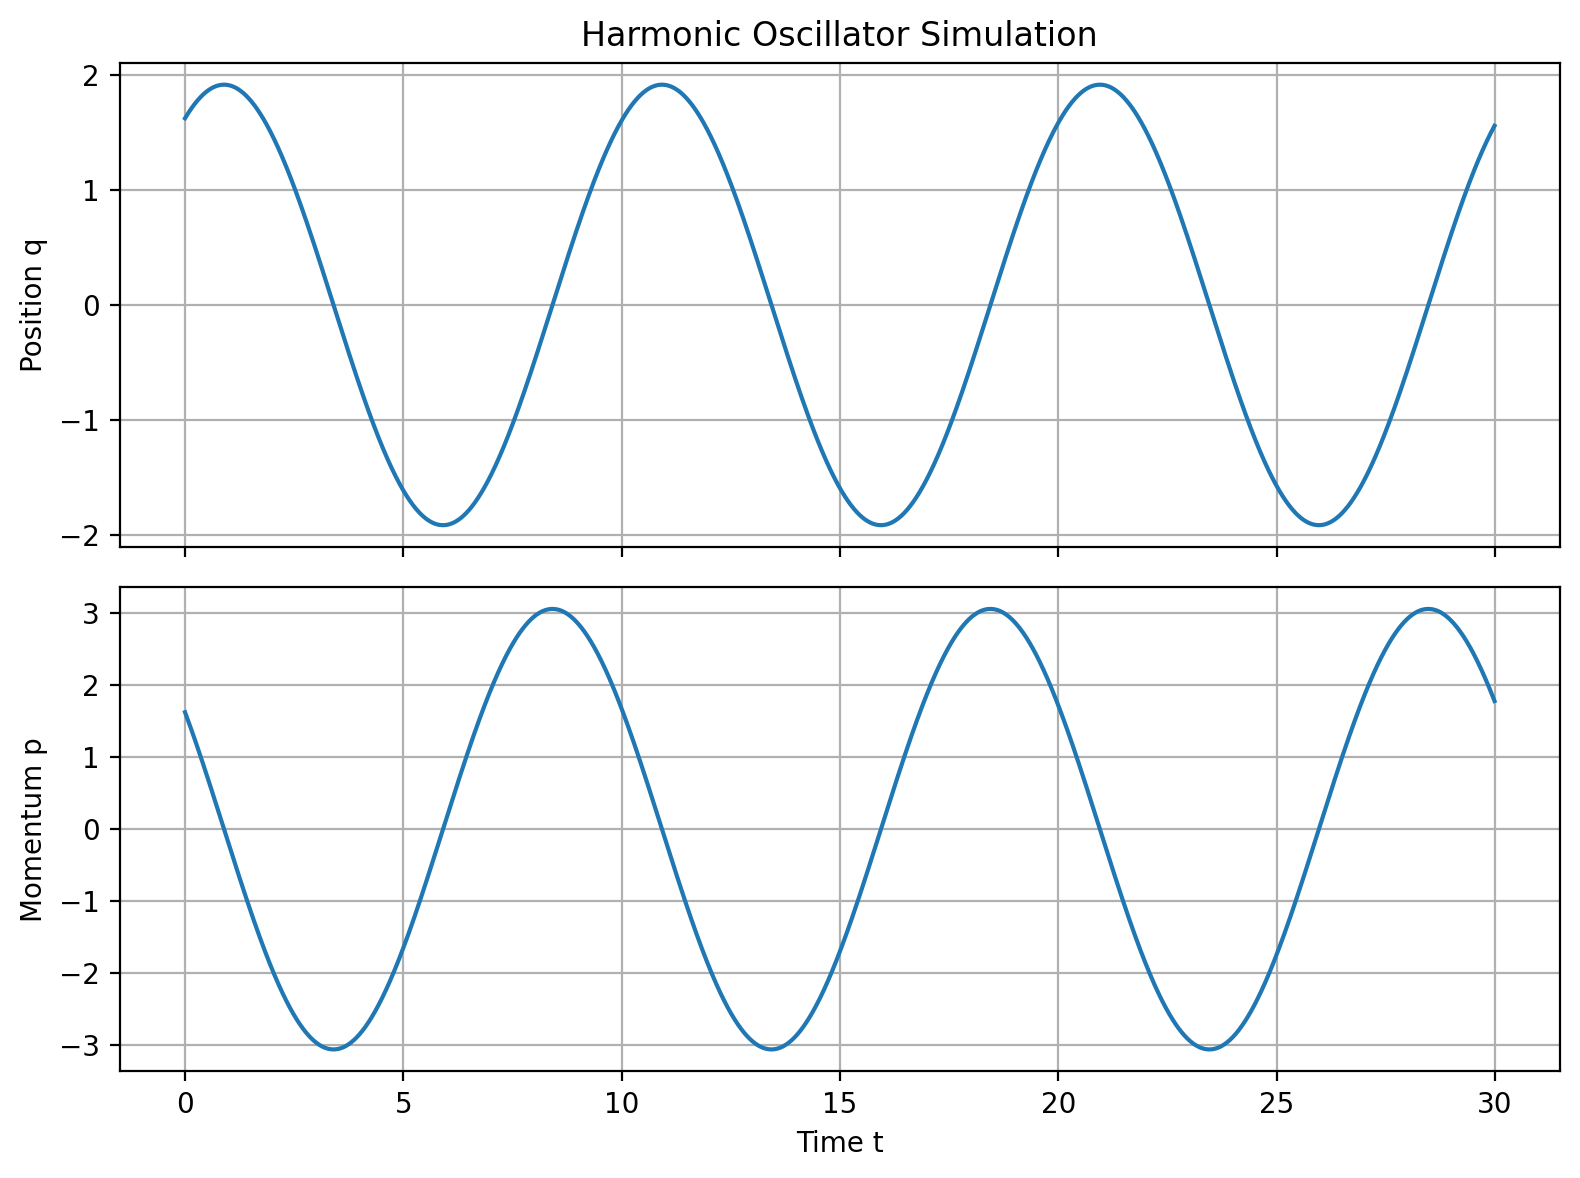

In [109]:
# plot q and p
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t, q)
ax[0].set_ylabel('Position q')
ax[0].set_title('Harmonic Oscillator Simulation')
ax[0].grid()
ax[1].plot(t, p)
ax[1].set_ylabel('Momentum p')
ax[1].set_xlabel('Time t')
ax[1].grid()
plt.tight_layout()
plt.show()

# Prepare the dataset
Here we settle up the dataset for training. Let $x=(q, p) \in X,\; \dot{x} = (\dot{q}, \dot{p})$, and the flow $\varphi_t: X \to X$ follow $\dot{x} = J\nabla_xH$. We define the dataset $\mathcal{D}$ as
\begin{equation}
\mathcal{D} = \{(x_0, \dot{x}_0, x(t), t) \mid x_0 \in X,\; \dot{x}_0 = J\nabla H(x_0),\; x(t) = \varphi_t(x),\; t\in\mathbb{R}_{>0}\}.
\end{equation}

To create such a dataset (technically, a finite subset of the dataset define above), we sample 
+ $x_0$ from a compact set
+ $t$ with an upper bount $t_{\text{max}}$


In [110]:
#hyper_params = set_harmonic_params(n=n, m=m, k_wall=k_wall, k_pair=k_pair)
hyper_params = set_harmonic_params(n=n, m=m[:n], k_wall=k_wall, k_pair=k_pair)


In [111]:
def create_dataset(x0, t, dt=dt, hyper_params=hyper_params):
    """
    x0: (B, 2n) initial conditions
    t: (B,) time steps for each batch
    Returns:
    x0: (B, 2n)
    x0_dot: (B, 2n)
    xt: (B, 2n)
    t: (B,)
    """
    B, dim = x0.shape
    n = dim // 2
    q0 = x0[:, :n]
    p0 = x0[:, n:]

    t, q, p, _ = flow_coupled_1d_harmonic_init_values(
        params=set_harmonic_params(n=n, m=hyper_params.m, k_wall=hyper_params.k_wall, k_pair=hyper_params.k_pair),
        num_steps=tuple(t.tolist()),
        dt=dt,
        q0=q0,
        p0=p0
    )
    xt = jnp.concatenate([q, p], axis=1)  # (B, 2n)

    # compute x0_dot
    dqdt0 = p0 / hyper_params.m[None, :]  # (B, n)
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(hyper_params.k_wall + n * hyper_params.k_pair) * I + hyper_params.k_pair * J
    dpdt0 = jnp.matmul(q0, jnp.asarray(L).T)  # (B, n)
    x0_dot = jnp.concatenate([dqdt0, dpdt0], axis=1)  # (B, 2n)

    return x0, x0_dot, xt, t
    

In [174]:
N_train = 100000
N_test  = 25000
delta_t_max = 0.5
train_t_dist = "LNP" # "uniform", "step_scheduling", "LNP"

# Below ignored unless "LNP"
delta_t_mean = 0.1
sigma2 = 0.2

key = jax.random.PRNGKey(0)
q_train_key, p_train_key, dt_train_key, key = jax.random.split(key, 4)
q0_train = jax.random.uniform(q_train_key, shape=(N_train, n), minval=-1.0, maxval=1.0)
p0_train = jax.random.uniform(p_train_key, shape=(N_train, n), minval=-1.0, maxval=1.0)

if train_t_dist == "uniform":
    
    delta_t_train = jnp.clip(
        dt * jax.random.randint(dt_train_key, shape=(N_train,), minval=1, maxval=delta_t_max),
        min=dt,
        max=delta_t_max
    )
elif train_t_dist == "step_scheduling":
    unif_vec = jax.random.uniform(dt_train_key, shape=(N_train,), minval=0.0, maxval=1.0)
    delta_t_train = jnp.clip(
        dt * jnp.ceil( unif_vec * ((delta_t_max * jnp.arange(N_train)/N_train)//dt)),
        min=dt,
        max=delta_t_max
    )
elif train_t_dist == "LNP":
    sigma2 =  1.0 / 2.0
    dt_train_key, dt_train_key2 = jax.random.split(dt_train_key, 2)
    tau = jnp.sqrt(sigma2) * jax.random.normal( key=dt_train_key, shape=(N_train,) ) + jnp.log( float(delta_t_mean//dt-1) ) - 0.5 * sigma2
    # tau ~ N(log(T_mean-1)-0.5*sigma^2, sigma)
    delta_t_train = dt* (jax.random.poisson(key=dt_train_key2, lam=jnp.exp(tau)) + 1)

q_test_key, p_test_key, dt_test_key = jax.random.split(key, 3)
q0_test = jax.random.uniform(q_test_key, shape=(N_test, n), minval=-3.0, maxval=3.0)
p0_test = jax.random.uniform(p_test_key, shape=(N_test, n), minval=-3.0, maxval=3.0)
delta_t_test = jax.random.uniform(dt_test_key, shape=(N_test,), minval=0.01, maxval=30.0)

step_counts_train = jnp.maximum(1, jnp.round(delta_t_train / dt).astype(int))
step_counts_test = jnp.maximum(1, jnp.round(delta_t_test / dt).astype(int))

train_dataset = create_dataset(
    x0=jnp.concatenate([q0_train, p0_train], axis=1),
    t=step_counts_train,
    dt=dt,
    hyper_params=hyper_params
)
test_dataset = create_dataset(
    x0=jnp.concatenate([q0_test, p0_test], axis=1),
    t=step_counts_test,
    dt=dt,
    hyper_params=hyper_params
)

/tmp/1010120.2404/ipykernel_150483/915626916.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


In [175]:
delta_t_mean = 0.1
sigma2 =  1.0/2.0
dt_train_key, dt_train_key2 = jax.random.split(dt_train_key, 2)
tau = jnp.sqrt(sigma2) * jax.random.normal( key=dt_train_key, shape=(N_train,) ) + jnp.log( float(delta_t_mean//dt-1) ) - 0.5 * sigma2
tt = jax.random.poisson(key=dt_train_key2, lam=jnp.exp(tau)) + 1

In [176]:
print(tt)

[6 7 3 ... 7 6 2]


In [177]:
print(jnp.max(tt), jnp.min(tt))

167 1


(array([1.3586e+04, 2.5261e+04, 2.1116e+04, 1.0246e+04, 1.0548e+04,
        6.4980e+03, 4.2060e+03, 1.9190e+03, 2.0430e+03, 1.4040e+03,
        6.4500e+02, 6.9600e+02, 4.8700e+02, 3.7200e+02, 1.6700e+02,
        2.1700e+02, 1.3000e+02, 8.6000e+01, 9.0000e+01, 6.5000e+01,
        6.1000e+01, 3.0000e+01, 3.4000e+01, 1.5000e+01, 1.2000e+01,
        1.1000e+01, 7.0000e+00, 8.0000e+00, 4.0000e+00, 7.0000e+00,
        5.0000e+00, 7.0000e+00, 3.0000e+00, 4.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        2.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([  1.  ,   3.72,   6.44,   9.16,  11.88,  14.6 ,  17.32,  20.04,
         22.76,  25.48,  28.2 ,  30.92,  33.64,  36.36,  39.08,  41.8 ,
         44.52,  47.24,  49.96,  52.68,  55.4 ,  58.12,  60.84,  63.56,
         66.28,  69.  ,  71.72,  74.44,  77.16,  79.88,  82.6 ,  85.32,
         88.04,  90.76,  93.48

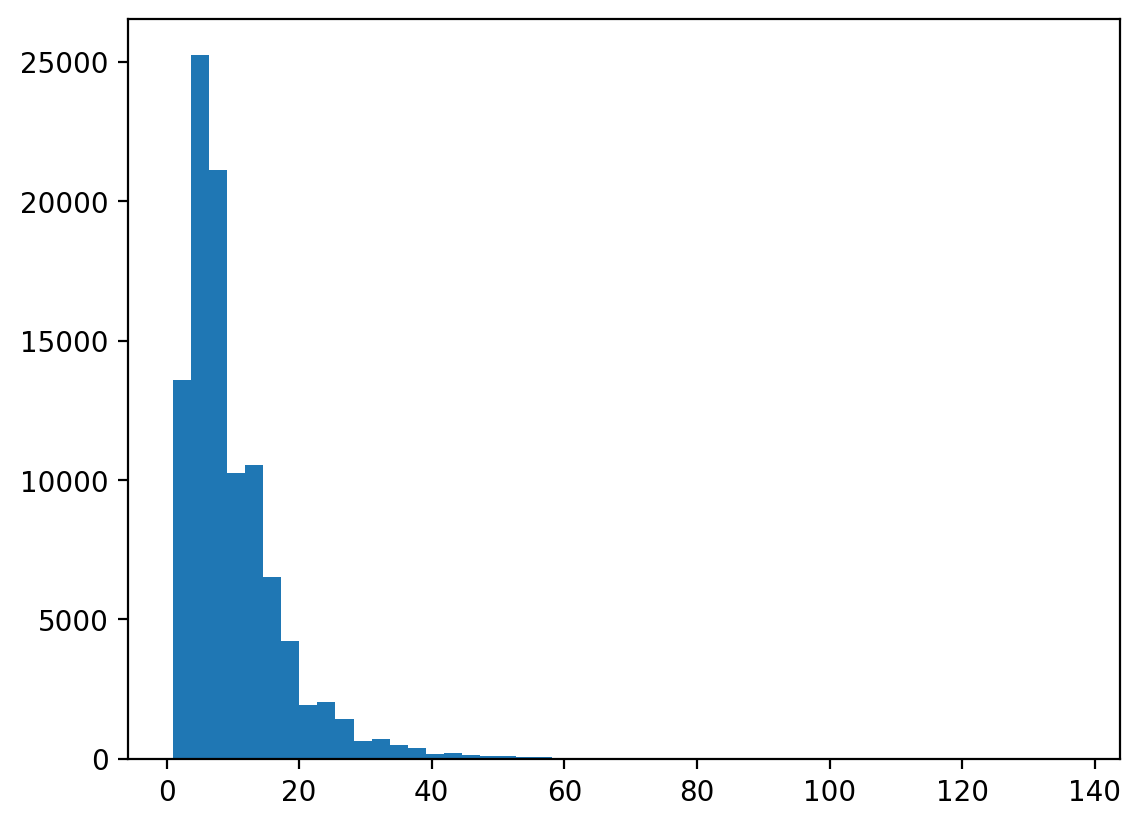

In [178]:
plt.hist(rr, bins=50)

# Build model & train

In [179]:
model = MyActionAngleNetwork(
    dim_config=n,
    dim_hidden_list=[64, 64, 64],
    num_gsblocks=20,
    type_polar="canonical",
    activation=nn.silu,
    mlp_res_connection=False,
    theta_predictor="gradient",
    learn_scale=True
)


In [180]:
rng = jax.random.PRNGKey(0)
q0 = jnp.zeros((1, int(n)))
p0 = jnp.zeros((1, int(n)))
delta_t0 = jnp.asarray(0.1)

variables = model.init(rng, q0, p0, delta_t0)
params = variables['params']
num_params = sum(jax.tree_util.tree_leaves(jax.tree_util.tree_map(lambda x: x.size, params)))
print(f'Total parameters: {num_params}')


Total parameters: 12375


# Training

In [181]:
# --- New helper: batched ∂H/∂q, ∂H/∂p ---
# def H_gt_grad_batch(q: jnp.ndarray, p: jnp.ndarray, gt_params):
#     """
#     q, p: (B, n) -> dHdq, dHdp each (B, n)
#     """
#     def Hsum(q, p):
#         return harmonic_hamiltonian_jax(q, p, gt_params).sum()

#     dHdq, dHdp = jax.grad(Hsum, argnums=(0, 1))(q, p)
#     return dHdq, dHdp


def train_step(params,
               opt_state,
               dtst_batch,
               apply_fn,
               tx,
               loss_weights=(1.0, 1.0, 0.0, 0.0),
               action_loss_type='var'):
    x, x_dot, y, delta_t = dtst_batch  # x, x_dot, y: (B, 2n), delta_t: (B,)    
    
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, n), (B, n)
    q_dot, p_dot = x_dot[:, :n], x_dot[:, n:]

    # dHdq_gt, dHdp_gt = H_gt_grad_batch(q, p, gt_params)

    # def H_hat_single(pp, qi, pi):
    #     return apply_fn({'params': pp}, qi[None, :], pi[None, :],
    #                     method=model.hamiltonian).squeeze()

    # grad_q_H_hat_single = jax.grad(H_hat_single, argnums=1)
    # grad_p_H_hat_single = jax.grad(H_hat_single, argnums=2)
    # dHdq_model = jax.vmap(lambda qi, pi: grad_q_H_hat_single(params, qi, pi))(q, p)
    # dHdp_model = jax.vmap(lambda qi, pi: grad_p_H_hat_single(params, qi, pi))(q, p)

    def loss_fn(pp):
        q_, p_, I, _ = apply_fn({'params': pp}, q, p, delta_t, train=True)

        loss_q_se = ((q_ - y[:, :n]) ** 2).mean()
        loss_p_se = ((p_ - y[:, n:]) ** 2).mean()

        def H_hat_single(qi, pi):
            return apply_fn({'params': pp}, qi[None, :], pi[None, :],
                            method=model.hamiltonian).squeeze()

        dHdq_model = jax.vmap(lambda qi, pi: jax.grad(H_hat_single, argnums=0)(qi, pi))(q, p)
        dHdp_model = jax.vmap(lambda qi, pi: jax.grad(H_hat_single, argnums=1)(qi, pi))(q, p)

        L_HNN = ((dHdq_model + p_dot) ** 2).mean() + ((dHdp_model - q_dot) ** 2).mean()

        if action_loss_type=='var':
            L_action = lax.cond(
                loss_weights[2] > 0.0,
                lambda I: jnp.var(I, axis=0).sum(),
                lambda I: 0.0,
                I
            )
        elif action_loss_type=='quadratic_variation':
            L_action = jnp.sum(jnp.square(I[1:, :] - I[:-1, :])) / I.shape[0]


        return (loss_weights[0] * loss_q_se +
                loss_weights[1] * loss_p_se +
                loss_weights[2] * L_action +
                loss_weights[3] * L_HNN)
        #return loss_q_se + loss_p_se + alpha * L_action + beta * L_HNN

    loss, grads = value_and_grad(loss_fn)(params)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


train_step_jit = jax.jit(train_step, static_argnames=('apply_fn', 'tx'))


In [182]:
@partial(jax.jit, static_argnames=('apply_fn',))
def eval_batch(params, x, y, delta_t, *, apply_fn):
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]

    q_, p_, _, _ = apply_fn({'params': params}, q, p, delta_t, train=False)

    loss_q_mse = ((q_ - y[:, :n]) ** 2).mean()
    loss_p_mse = ((p_ - y[:, n:]) ** 2).mean()

    return loss_q_mse + loss_p_mse


In [183]:
dt

0.01

In [184]:
# --- Replace: 学習ループの該当部分 ---
seed = 201
lr = 1e-3
batch_size = 256
epoch = 5
ep_shuffle_chunks = 4

log_every = 50
loss_weights = (1.0, 1.0, 0.0, 1.0)
delta_t = dt  # base time step
delta_t_max = 0.5  # max jump multiplier during training


key = jax.random.PRNGKey(seed)
variables = model.init(key, jnp.zeros((1, n)), jnp.zeros((1, n)), jnp.asarray(dt))
nn_params = variables['params']

tx = optax.adam(learning_rate=lr)
opt_state = tx.init(nn_params)

idx_serial_batch = 0
batch_losses = []

for ep in range(epoch):
    
    if ep == 0:
        x0_train, x0_dot_train, xt_train, t_train = train_dataset
    else:
        # Shuffle training data
        # なんとなくtを最初の方は短く→あとで長くとトレーニングしたいので、何チャンクかにわけてそのチャンク内でシャッフル
        # epoch=1なら関係ない
        for idx_ep in range(ep_shuffle_chunks):
            perm_key, key = jax.random.split(key)
            perm = jax.random.permutation(perm_key, N_train // ep_shuffle_chunks)
            start_idx = idx_ep * (N_train // ep_shuffle_chunks)
            end_idx = (idx_ep + 1) * (N_train // ep_shuffle_chunks)
            x0_train, x0_dot_train, xt_train, t_train = train_dataset
            x0_train = x0_train.at[start_idx:end_idx].set(x0_train[start_idx:end_idx][perm])
            x0_dot_train = x0_dot_train.at[start_idx:end_idx].set(x0_dot_train[start_idx:end_idx][perm])
            xt_train = xt_train.at[start_idx:end_idx].set(xt_train[start_idx:end_idx][perm])
            t_train = t_train.at[start_idx:end_idx].set(t_train[start_idx:end_idx][perm])
    
    # Mini-batch training
    num_batches = N_train // batch_size
    epoch_loss = 0.0

    for i in range(num_batches):
        batch_x0 = x0_train[i*batch_size:(i+1)*batch_size]
        batch_x0_dot = x0_dot_train[i*batch_size:(i+1)*batch_size]
        batch_xt = xt_train[i*batch_size:(i+1)*batch_size]
        batch_t = t_train[i*batch_size:(i+1)*batch_size]

        nn_params, opt_state, batch_loss = train_step_jit(
            nn_params, opt_state,
            (batch_x0, batch_x0_dot, batch_xt, batch_t),
            apply_fn=model.apply, tx=tx,
            loss_weights=loss_weights
        )
        total_batch_loss = batch_loss * len(batch_t)
        epoch_loss += total_batch_loss
        #epoch_loss += batch_loss *         
        batch_losses.append(batch_loss)

        if (idx_serial_batch + 1) % log_every == 0:
            print(f"Epoch {ep+1}, Batch {i+1}/{num_batches}, Loss: {batch_loss:.6f}")

        if (idx_serial_batch + 1) % log_every == 0 or idx_serial_batch == 1 or (ep==epoch-1 and i==num_batches-1):
            test_losses = []
            num_test_batches = N_test // batch_size
            for j in range(num_test_batches):
                batch_x0_test = test_dataset[0][j*batch_size:(j+1)*batch_size]
                batch_x0_dot_test = test_dataset[1][j*batch_size:(j+1)*batch_size]
                batch_xt_test = test_dataset[2][j*batch_size:(j+1)*batch_size]
                batch_t_test = test_dataset[3][j*batch_size:(j+1)*batch_size]

                test_loss = eval_batch(
                    nn_params,
                    batch_x0_test,
                    batch_xt_test,
                    batch_t_test,
                    apply_fn=model.apply
                )
                test_losses.append(test_loss * len(batch_t_test))
            total_test_loss = sum(test_losses) / N_test
            print(f"*** Test Loss after {idx_serial_batch} batches: {total_test_loss:.6f} ***")
        
        idx_serial_batch += 1

    epoch_loss /= N_train
    print(f"Epoch {ep+1} completed. Average Loss: {epoch_loss:.6f}")

    


*** Test Loss after 1 batches: 191632928.000000 ***
Epoch 1, Batch 50/390, Loss: 496.761353
*** Test Loss after 49 batches: 1124628.375000 ***
Epoch 1, Batch 100/390, Loss: 2.213629
*** Test Loss after 99 batches: 4431.026367 ***
Epoch 1, Batch 150/390, Loss: 0.227865
*** Test Loss after 149 batches: 492.870239 ***
Epoch 1, Batch 200/390, Loss: 0.185944
*** Test Loss after 199 batches: 574.165527 ***
Epoch 1, Batch 250/390, Loss: 0.191695
*** Test Loss after 249 batches: 577.381348 ***
Epoch 1, Batch 300/390, Loss: 0.196739
*** Test Loss after 299 batches: 718.165833 ***
Epoch 1, Batch 350/390, Loss: 0.216676
*** Test Loss after 349 batches: 718.074219 ***
Epoch 1 completed. Average Loss: 7061.819336
Epoch 2, Batch 10/390, Loss: 0.204740
*** Test Loss after 399 batches: 579.342285 ***
Epoch 2, Batch 60/390, Loss: 0.197116
*** Test Loss after 449 batches: 579.317444 ***
Epoch 2, Batch 110/390, Loss: 0.182144
*** Test Loss after 499 batches: 578.394592 ***
Epoch 2, Batch 160/390, Loss: 0

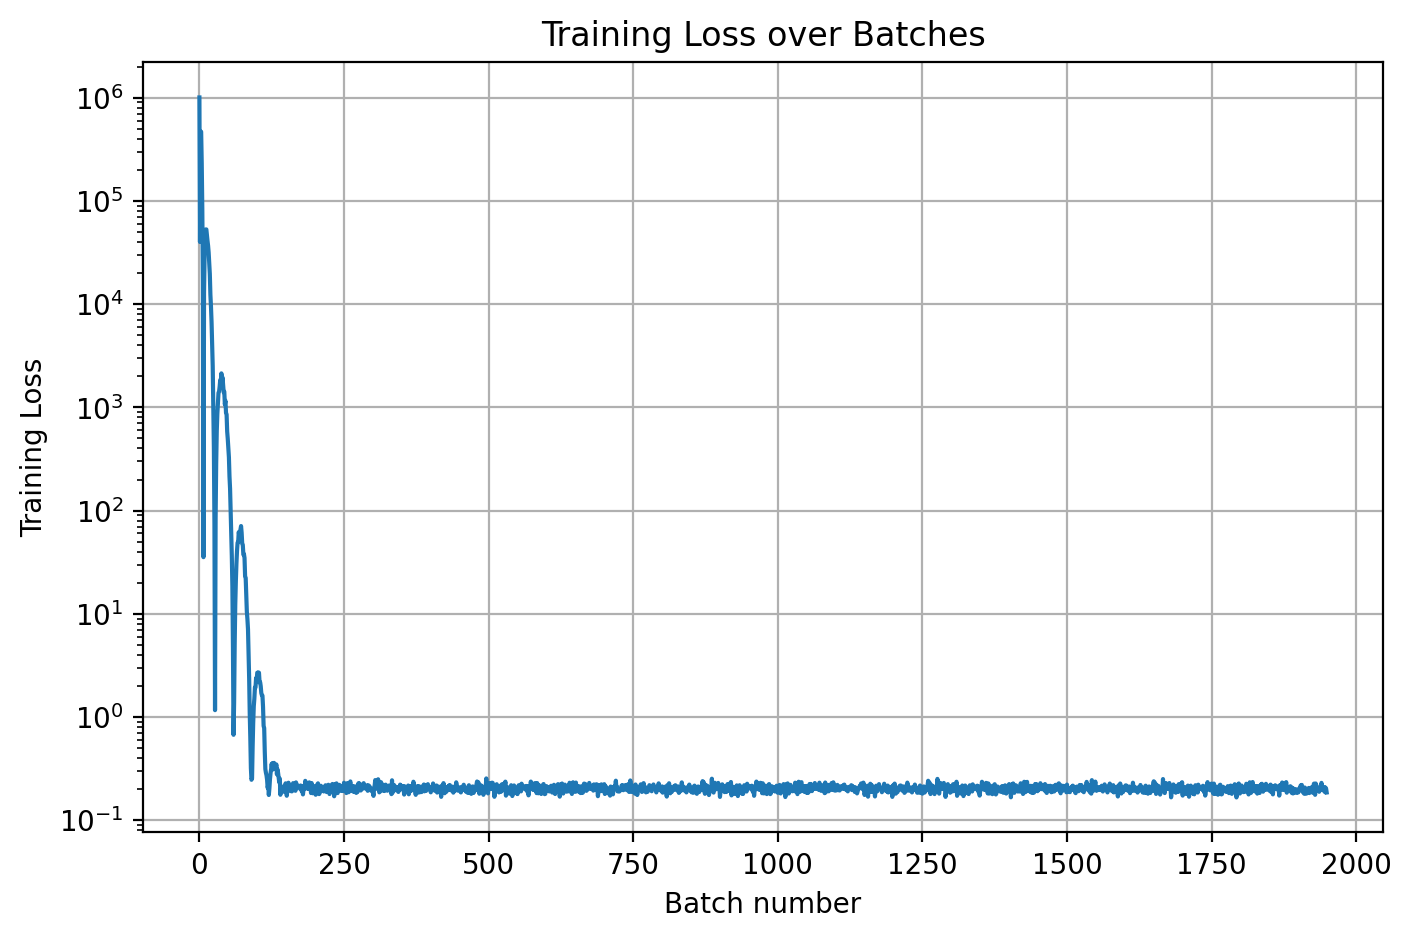

In [185]:
ax, fig = plt.subplots(figsize=(8, 5))
fig.plot(batch_losses)
fig.set_yscale('log')
fig.set_xlabel('Batch number')
fig.set_ylabel('Training Loss')
fig.set_title('Training Loss over Batches')
fig.grid()
plt.show()

In [186]:
q0

Array([[0.]], dtype=float32)

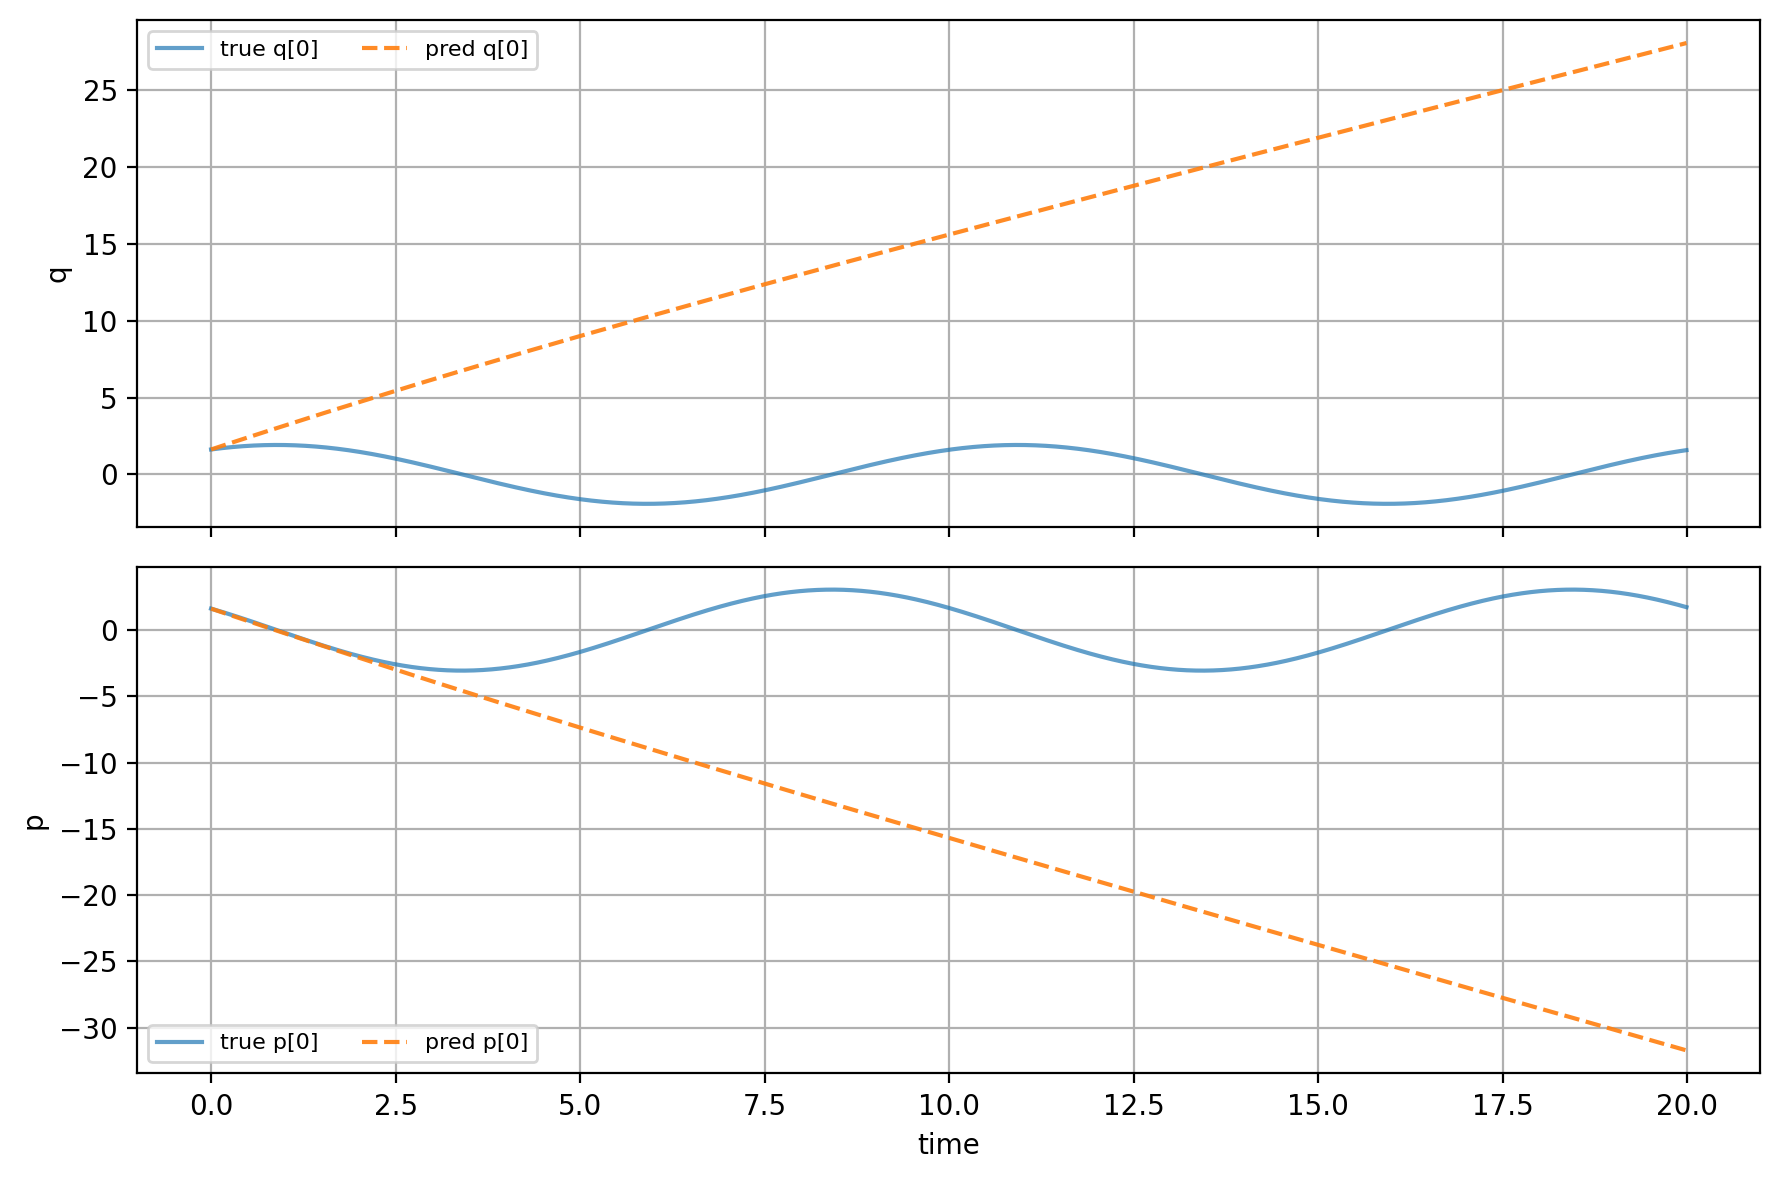

In [187]:

# --- 真値 vs モデル予測（同一初期値）---

T_total = 2000  # 欲しいステップ数に合わせて調整
q_true = jnp.asarray(q)
p_true = jnp.asarray(p)

q0 = q_true[:1]  # shape (1, n)
p0 = p_true[:1]
delta_t_infer = jnp.asarray(dt)

def step_fn(carry, _):
    q_curr, p_curr = carry
    q_next, p_next, _, _ = model.apply(
        {'params': nn_params}, q_curr, p_curr, delta_t_infer, train=False
    )
    return (q_next, p_next), (q_next, p_next)

if T_total <= 1:
    q_pred = q0
    p_pred = p0
else:
    (_, _), (qs_seq, ps_seq) = jax.lax.scan(
        step_fn, (q0, p0), None, length=T_total - 1
    )
    if qs_seq.ndim == 3:
        qs_seq = jnp.squeeze(qs_seq, axis=1)
        ps_seq = jnp.squeeze(ps_seq, axis=1)
    q_pred = jnp.concatenate([q0, qs_seq], axis=0)
    p_pred = jnp.concatenate([p0, ps_seq], axis=0)

t_arr = np.asarray(t[:T_total])
q_true_np = np.asarray(q_true)[:T_total]
p_true_np = np.asarray(p_true)[:T_total]
q_pred_np = np.asarray(q_pred)
p_pred_np = np.asarray(p_pred)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for i in range(q_pred_np.shape[1]):
    axes[0].plot(t_arr, q_true_np[:, i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, q_pred_np[:, i], '--', label=f'pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

for i in range(p_pred_np.shape[1]):
    axes[1].plot(t_arr, p_true_np[:, i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, p_pred_np[:, i], '--', label=f'pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()



# Diagnostics

We compare our model to the ground truth Hamiltonian:
\begin{equation}
H(q, p)=\sum_{i=1}^n \frac{p_i^2}{2 m_i}+\frac{k_{\text {wall }}}{2} \sum_{i=1}^n q_i^2+\frac{k_{\text {pair }}}{2} \sum_{1 \leq i < j \leq n} \left( q_i-q_j \right)^2, 
\end{equation}
or
\begin{align}
H =~& \frac{1}{2} p^\top M p + \frac{1}{2} q^\top\left(k_{\mathrm{wall}} I+k_{\mathrm{pair}}\left(n I-\mathbf{1 1}^{\top}\right)\right) q \\
=~&  \frac{1}{2} p^\top M p + \frac{1}{2} q^\top K q
\end{align}
and the ground truth action and anlge:
\begin{equation}
I_j = \frac{1}{2\omega_j} (p)
\end{equation}
(unfinished cell)

In [65]:

# --- Hamiltonian diagnostics utilities ---
import numpy as _np

def _make_m_k(sim_params):
    n_loc = int(sim_params.n)
    m_loc = _np.asarray(sim_params.m, dtype=float)
    k_wall_loc = float(sim_params.k_wall)
    k_pair_loc = float(sim_params.k_pair)
    M = _np.diag(m_loc)
    J = _np.ones((n_loc, n_loc))
    K = k_wall_loc * _np.eye(n_loc) + k_pair_loc * (n_loc * _np.eye(n_loc) - J)
    return M, K

def H_ground_truth(q_arr, p_arr, sim_params):
    q_arr = _np.atleast_2d(_np.asarray(q_arr))
    p_arr = _np.atleast_2d(_np.asarray(p_arr))
    M, K = _make_m_k(sim_params)
    Minv = _np.linalg.inv(M)
    kin = 0.5 * _np.einsum('ti,ij,tj->t', p_arr, Minv, p_arr)
    pot = 0.5 * _np.einsum('ti,ij,tj->t', q_arr, K, q_arr)
    return kin + pot

def action_angle_ground_truth(q_arr, p_arr, sim_params):
    q_arr = _np.atleast_2d(_np.asarray(q_arr))
    p_arr = _np.atleast_2d(_np.asarray(p_arr))
    n_loc = int(sim_params.n)
    m_loc = _np.asarray(sim_params.m, dtype=float)
    M = _np.diag(m_loc)
    Minv_sqrt = _np.diag(1.0 / _np.sqrt(m_loc))
    Msqrt = _np.diag(_np.sqrt(m_loc))
    _, K = _make_m_k(sim_params)
    A = Minv_sqrt @ K @ Minv_sqrt
    w2, U = _np.linalg.eigh(A)
    omega = _np.sqrt(_np.clip(w2, a_min=0.0, a_max=None))
    y = (Msqrt @ q_arr.T).T
    pi = (Minv_sqrt @ p_arr.T).T
    xi = (U.T @ y.T).T
    rho = (U.T @ pi.T).T
    omega_safe = _np.where(omega > 0, omega, 1.0)
    I = 0.5 * ((rho ** 2) + (omega[None, :] ** 2) * (xi ** 2)) / omega_safe[None, :]
    theta = _np.arctan2(omega[None, :] * xi, rho)
    return I, theta, omega, U

def predict_hamiltonian(q_arr, p_arr):
    q_j = jnp.asarray(q_arr)
    p_j = jnp.asarray(p_arr)
    if q_j.ndim == 1:
        q_j = q_j[None, :]
    if p_j.ndim == 1:
        p_j = p_j[None, :]
    H_pred = model.apply({'params': nn_params}, q_j, p_j,
                         method=MyActionAngleNetwork.hamiltonian)
    return _np.asarray(H_pred)

def predict_action_angle(q_arr, p_arr):
    q_j = jnp.asarray(q_arr)
    p_j = jnp.asarray(p_arr)
    if q_j.ndim == 1:
        q_j = q_j[None, :]
    if p_j.ndim == 1:
        p_j = p_j[None, :]
    _, _, I_pred, theta_pred = model.apply({'params': nn_params}, q_j, p_j,
                                           jnp.asarray(0.0), train=False)
    return _np.asarray(I_pred), _np.asarray(theta_pred)



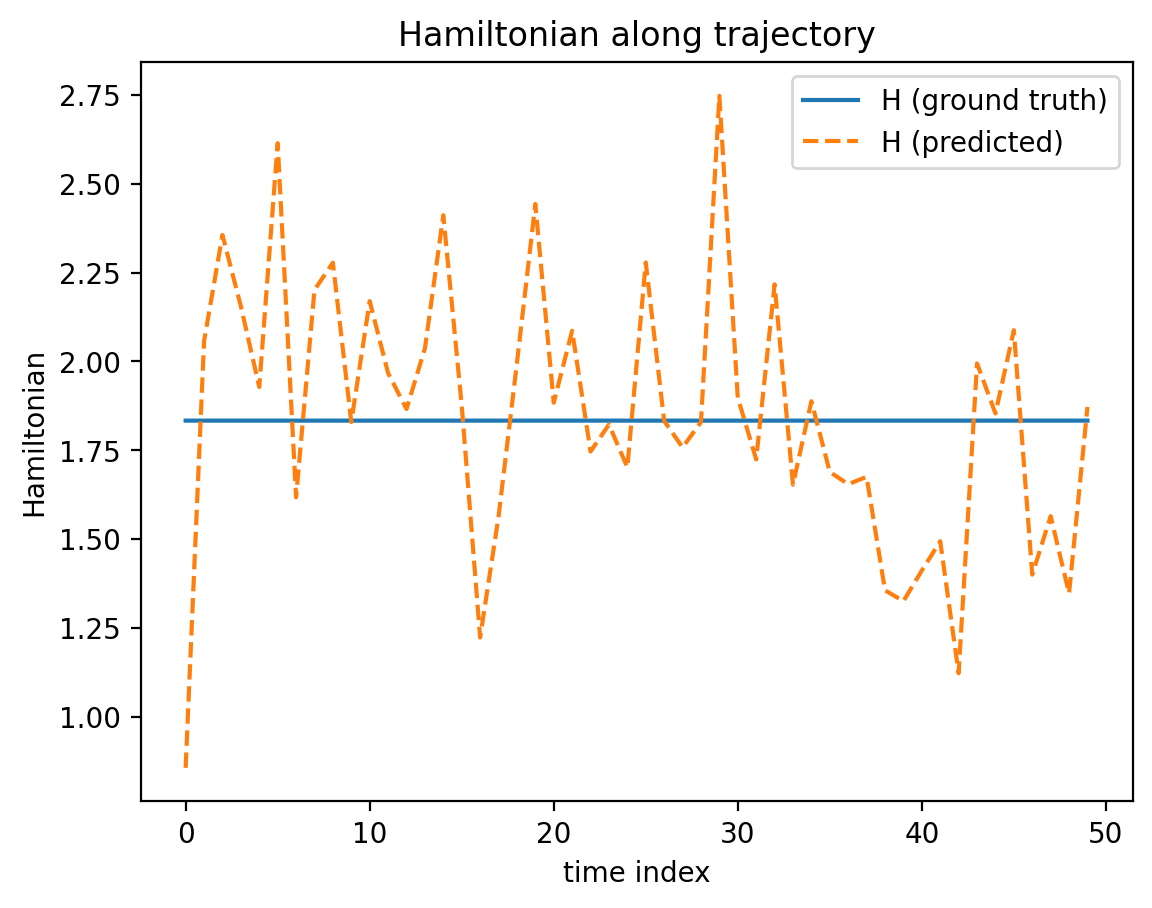

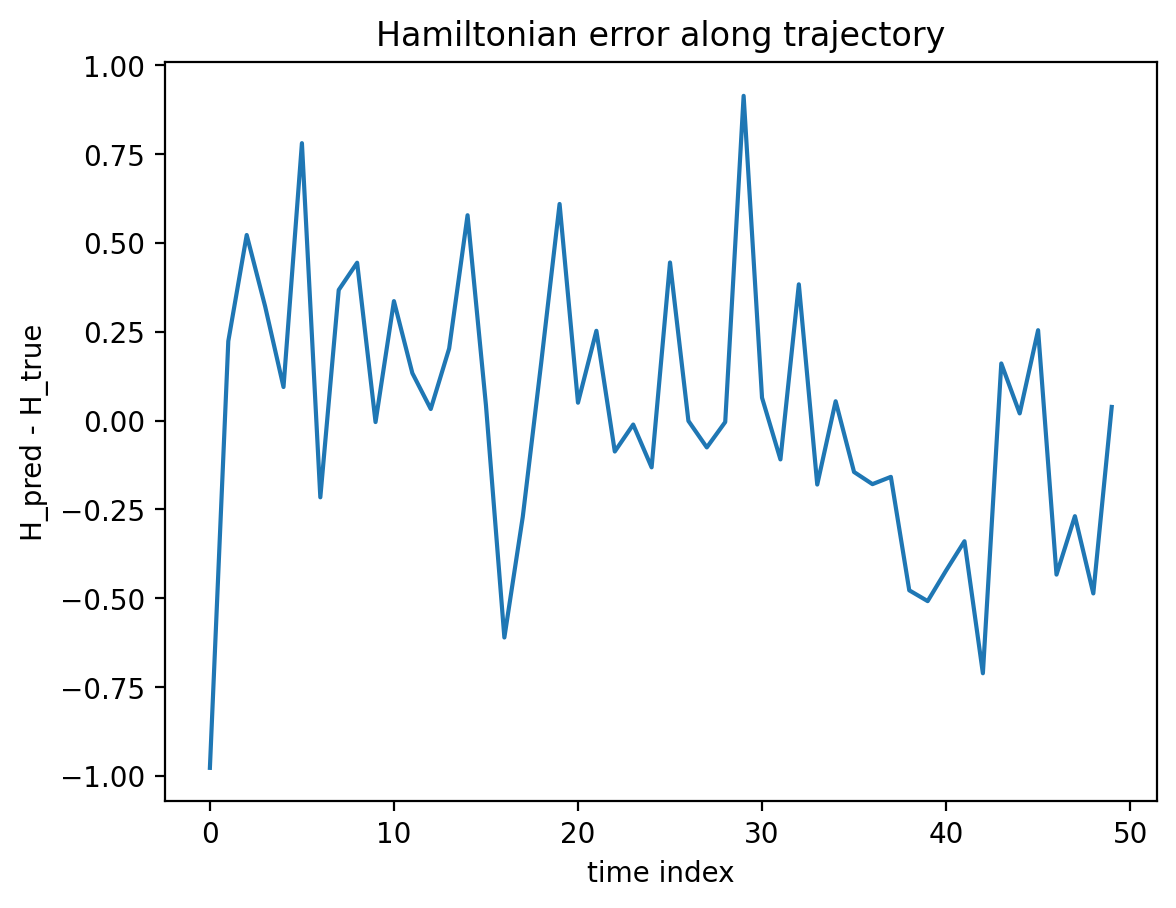

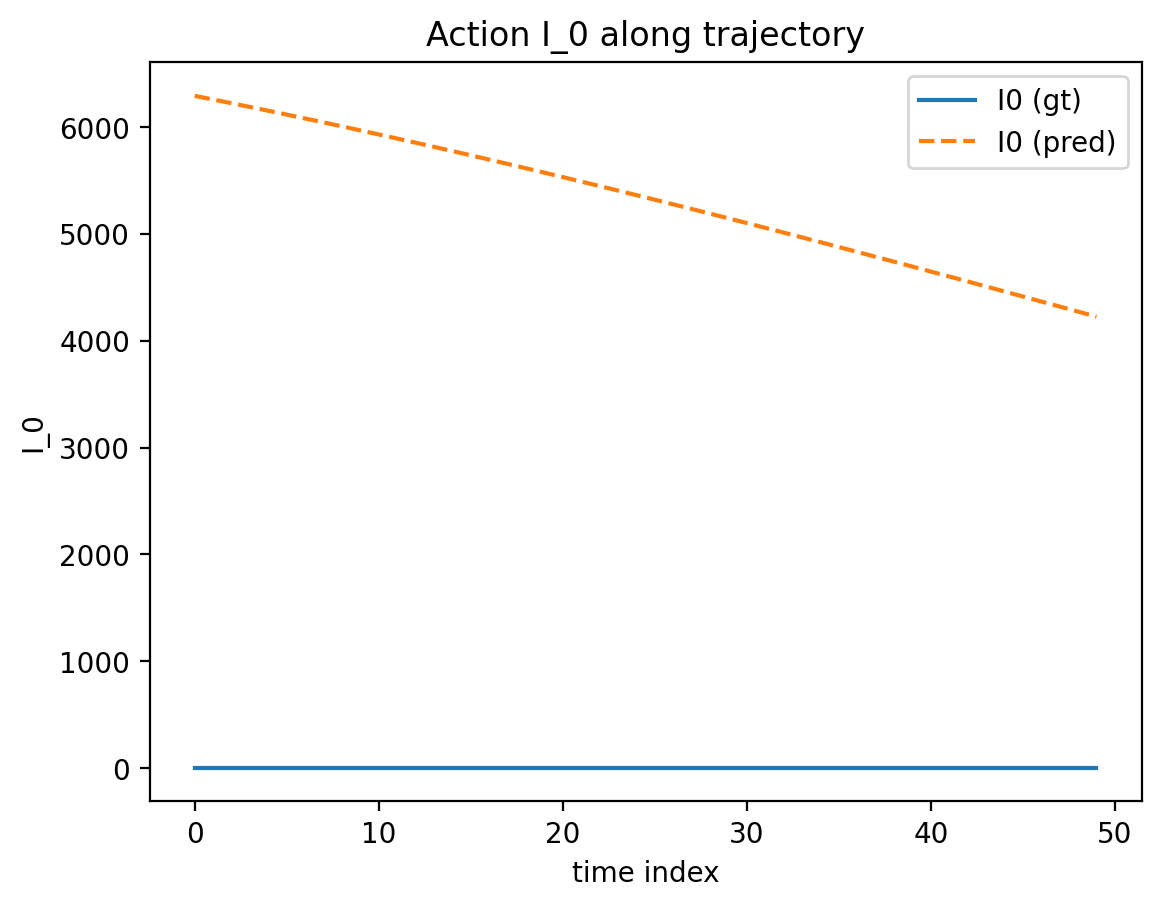

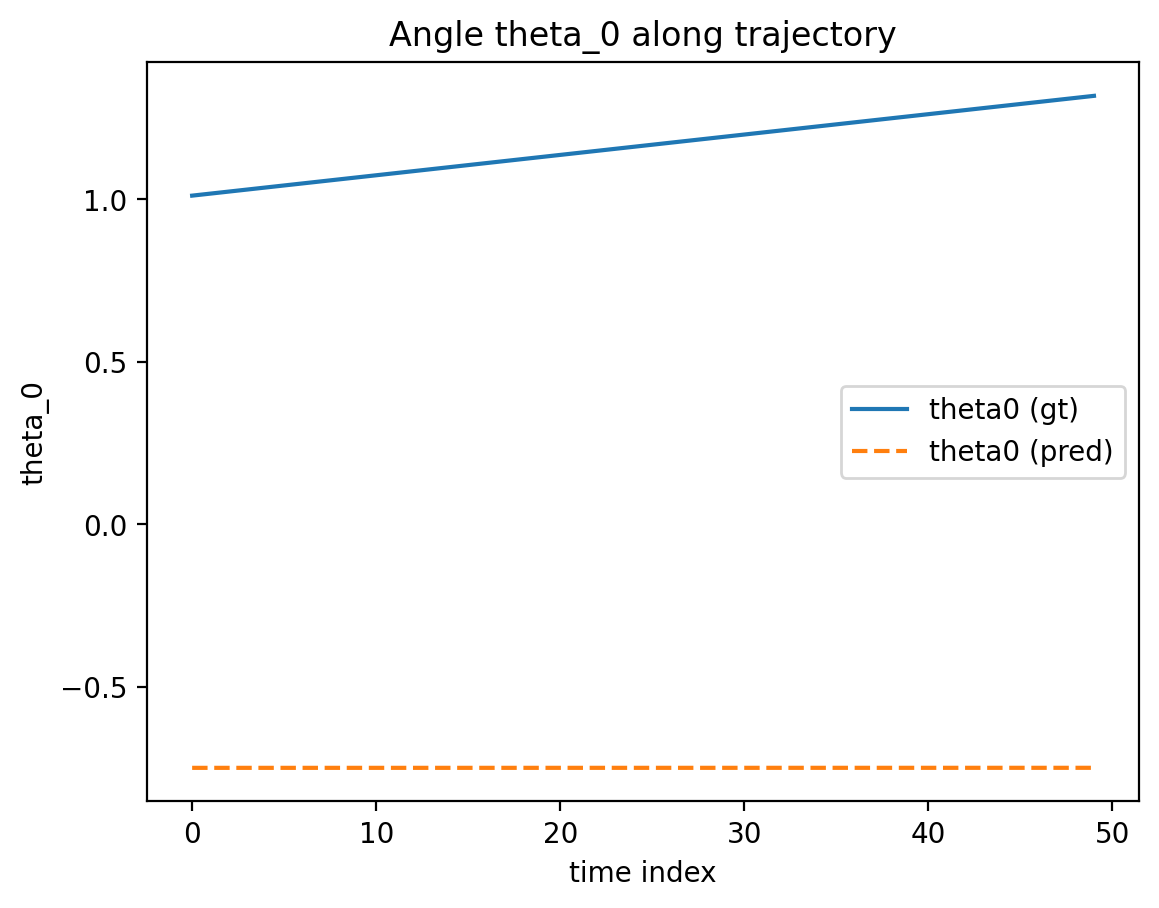

In [66]:

# --- Hamiltonian / action diagnostics ---
sim_params = hyper_params

q_plot = _np.asarray(q_true_np)
p_plot = _np.asarray(p_true_np)

H_true_vals = H_ground_truth(q_plot, p_plot, sim_params)
I_true_vals, theta_true_vals, omega_vals, U_vals = action_angle_ground_truth(q_plot, p_plot, sim_params)

H_pred_vals = predict_hamiltonian(q_plot, p_plot)
I_pred_vals, theta_pred_vals = predict_action_angle(q_plot, p_plot)

plt.figure()
plt.plot(H_true_vals, label='H (ground truth)')
plt.plot(H_pred_vals, '--', label='H (predicted)')
plt.xlabel('time index')
plt.ylabel('Hamiltonian')
plt.title('Hamiltonian along trajectory')
plt.legend()
plt.show()

plt.figure()
plt.plot(H_pred_vals - H_true_vals)
plt.xlabel('time index')
plt.ylabel('H_pred - H_true')
plt.title('Hamiltonian error along trajectory')
plt.show()

max_modes = min(4, I_true_vals.shape[1])
for j_mode in range(max_modes):
    plt.figure()
    plt.plot(I_true_vals[:, j_mode], label=f'I{j_mode} (gt)')
    plt.plot(I_pred_vals[:, j_mode], '--', label=f'I{j_mode} (pred)')
    plt.xlabel('time index')
    plt.ylabel(f'I_{j_mode}')
    plt.title(f'Action I_{j_mode} along trajectory')
    plt.legend()
    plt.show()

def _wrap_pi(arr):
    return (arr + np.pi) % (2 * np.pi) - np.pi

for j_mode in range(max_modes):
    plt.figure()
    plt.plot(_wrap_pi(theta_true_vals[:, j_mode]), label=f'theta{j_mode} (gt)')
    plt.plot(_wrap_pi(theta_pred_vals[:, j_mode]), '--', label=f'theta{j_mode} (pred)')
    plt.xlabel('time index')
    plt.ylabel(f'theta_{j_mode}')
    plt.title(f'Angle theta_{j_mode} along trajectory')
    plt.legend()
    plt.show()



In [28]:
# 検証用: n=1, B=4, dt=0.01
sample_steps = jnp.array([1, 2, 5, 10], dtype=int)
q0 = jnp.array([[1.0], [0.5], [-0.3], [0.0]])
p0 = jnp.array([[0.0], [0.2], [-0.1], [0.4]])

t_flow, q_flow, p_flow, _ = flow_coupled_1d_harmonic_init_values(
    params=hyper_params, num_steps=tuple(sample_steps.tolist()),
    dt=dt, q0=q0, p0=p0)

x0, x0_dot, xt, t_dataset = create_dataset(
    x0=jnp.concatenate([q0, p0], axis=1),
    t=sample_steps, dt=dt, hyper_params=hyper_params)

print(jnp.allclose(t_flow, t_dataset))
print(jnp.allclose(q_flow, xt[:, :1]))
print(jnp.allclose(p_flow, xt[:, 1:]))


/tmp/1010120.2404/ipykernel_150483/915626916.py:186: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  t = jnp.array([ns * float(dt) for ns in num_steps], dtype=jnp.float64) # shape (B,)


True
True
True


In [32]:
q0

Array([[ 1. ],
       [ 0.5],
       [-0.3],
       [ 0. ]], dtype=float32)

In [31]:
p0

Array([[ 0. ],
       [ 0.2],
       [-0.1],
       [ 0.4]], dtype=float32)

In [29]:
model.apply({'params':nn_params}, q0, p0, 0.0)

(Array([[ 9.9983412e-01],
        [ 4.9997208e-01],
        [-3.0001017e-01],
        [-4.1706586e-05]], dtype=float32),
 Array([[ 2.0410375e-04],
        [ 2.0003454e-01],
        [-9.9987291e-02],
        [ 4.0005177e-01]], dtype=float32),
 Array([[507.98444 ],
        [185.4482  ],
        [135.22527 ],
        [ 26.013494]], dtype=float32),
 Array([[-0.74850047],
        [-0.7466247 ],
        [ 2.418814  ],
        [-0.74147713]], dtype=float32))